# Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from scipy.stats import pointbiserialr
from statsmodels.stats.outliers_influence import variance_inflation_factor


# **Descripción de datos**

In [2]:
df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")
df

C:\Users\David\AppData\Local\Temp\ipykernel_16388\931507168.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## *Variables más importantes del estudio*

A continuación, se presenta una descripción resumida de las variables clave a considerar en el análisis, agrupadas por categorías.

### Variables del Préstamo y del Cliente 
Estas variables describen los detalles del préstamo y la información básica del solicitante. Son cruciales para evaluar el riesgo.

- **funded_amnt**: Monto del préstamo otorgado. A mayor monto, mayor riesgo potencial.  
- **term**: Duración del préstamo. Un plazo más largo aumenta el riesgo.  
- **int_rate**: Tasa de interés. Una tasa de interés alta indica mayor riesgo.  
- **installment**: El pago mensual. Refleja la carga de la deuda del cliente.  
- **grade** y **sub_grade**: Calificación de riesgo del préstamo. Es la variable más predictiva del conjunto.  
- **annual_inc**: Ingresos anuales del prestatario. Los ingresos más bajos pueden indicar mayor riesgo.  
- **emp_length**: Años de empleo del prestatario. La estabilidad laboral suele ser un buen indicador.  
- **home_ownership**: Propiedad de la vivienda. Un prestatario que posee casa es percibido como menos riesgoso.  
- **purpose**: Razón del préstamo. Algunas razones (ej. consolidación de deuda) pueden ser más riesgosas que otras.  
- **dti**: Relación deuda-ingreso. Un DTI alto indica que el prestatario está más cargado con deudas.  

---

### Variables del Historial Crediticio 
Estas variables provienen del reporte de crédito del prestatario y son vitales para predecir el comportamiento de pago.

- **fico_range_low** y **fico_range_high**: El rango de puntaje FICO. Un puntaje más alto indica un mejor historial de crédito.  
- **earliest_cr_line**: Antigüedad de la primera línea de crédito. Un historial más largo suele ser mejor.  
- **delinq_2yrs**: Número de morosidades en los últimos 2 años. Las morosidades son un fuerte predictor de riesgo.  
- **open_acc**: Número de cuentas de crédito abiertas. Puede indicar el manejo de crédito.  
- **pub_rec**: Número de registros públicos (ej. bancarrotas). La presencia de estos registros es señal de alto riesgo.  
- **revol_bal**: Saldo del crédito rotativo. Un saldo alto puede indicar uso excesivo de crédito.  
- **revol_util**: Tasa de utilización del crédito rotativo. Un alto uso del crédito disponible es un fuerte indicador de riesgo.  

---

### Variables de la Solicitud y Transacción 
Estas variables capturan la actividad reciente del prestatario y el estado de la transacción.

- **inq_last_6mths**: Consultas de crédito en los últimos 6 meses. Múltiples consultas pueden indicar un prestatario desesperado por crédito.  
- **initial_list_status**: Estado inicial del préstamo (listado o directo).  
- **disbursement_method**: Método de desembolso del préstamo.  

Ahora generamos una **variable binaria** llamada `default` que servirá como **variable objetivo** para nuestro modelo de predicción. La variable se basa en la columna original `loan_status`, la cual contiene distintos estados del préstamo.

In [3]:
#Crear variable binaria
df["default"] = df["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

- Para el análisis, solo nos interesa saber si el préstamo fue pagado en su totalidad o cayó en incumplimiento (**default**).
- Transformamos esta información en una variable binaria:
  - **`0`** → *Fully Paid* (pagado)
  - **`1`** → *Charged Off* (incumplimiento)

Luego eliminamos la columna original para evitar duplicidad. 

In [4]:
df_filtered = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df_filtered["default"] = df_filtered["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)
df_filtered["default"] = df_filtered["default"].astype('float64')
df_filtered = df_filtered.drop("loan_status", axis=1)

In [5]:
df_filtered

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,89905081,NaN,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2260690,88948836,NaN,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2260691,89996426,NaN,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2260692,90006534,NaN,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0.0


Luego del filtrado de la variable target, se redujo el número de registros de 2,260,701 a 1,345,310.

In [6]:
df_filtered.describe

<bound method NDFrame.describe of                id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
0        68407277        NaN     3600.0       3600.0           3600.0   
1        68355089        NaN    24700.0      24700.0          24700.0   
2        68341763        NaN    20000.0      20000.0          20000.0   
4        68476807        NaN    10400.0      10400.0          10400.0   
5        68426831        NaN    11950.0      11950.0          11950.0   
...           ...        ...        ...          ...              ...   
2260688  89905081        NaN    18000.0      18000.0          18000.0   
2260690  88948836        NaN    29400.0      29400.0          29400.0   
2260691  89996426        NaN    32000.0      32000.0          32000.0   
2260692  90006534        NaN    16000.0      16000.0          16000.0   
2260697  88224441        NaN    24000.0      24000.0          24000.0   

               term  int_rate  installment grade sub_grade  ...  \
0         36 months   

In [7]:
df_filtered.info

<bound method DataFrame.info of                id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
0        68407277        NaN     3600.0       3600.0           3600.0   
1        68355089        NaN    24700.0      24700.0          24700.0   
2        68341763        NaN    20000.0      20000.0          20000.0   
4        68476807        NaN    10400.0      10400.0          10400.0   
5        68426831        NaN    11950.0      11950.0          11950.0   
...           ...        ...        ...          ...              ...   
2260688  89905081        NaN    18000.0      18000.0          18000.0   
2260690  88948836        NaN    29400.0      29400.0          29400.0   
2260691  89996426        NaN    32000.0      32000.0          32000.0   
2260692  90006534        NaN    16000.0      16000.0          16000.0   
2260697  88224441        NaN    24000.0      24000.0          24000.0   

               term  int_rate  installment grade sub_grade  ...  \
0         36 months     

# **Análisis exploratorio**

## *Variable objetivo: Default*

In [8]:
# Conteo de la variable 'default'
count_table = df_filtered["default"].value_counts().rename_axis('default').reset_index(name='count')
percent_table = df_filtered["default"].value_counts(normalize=True).rename_axis('default').reset_index(name='proportion')

print("\nDistribución de la variable 'default':")
display(count_table.style.background_gradient(cmap='Purples_r', subset=['count']))

print("\nDistribución porcentual:")
display(percent_table.style.background_gradient(cmap='Purples_r', subset=['proportion']))



Distribución de la variable 'default':


,default,count
0,0.000000,1076751
1,1.000000,268559



Distribución porcentual:


,default,proportion
0,0.000000,0.800374
1,1.000000,0.199626


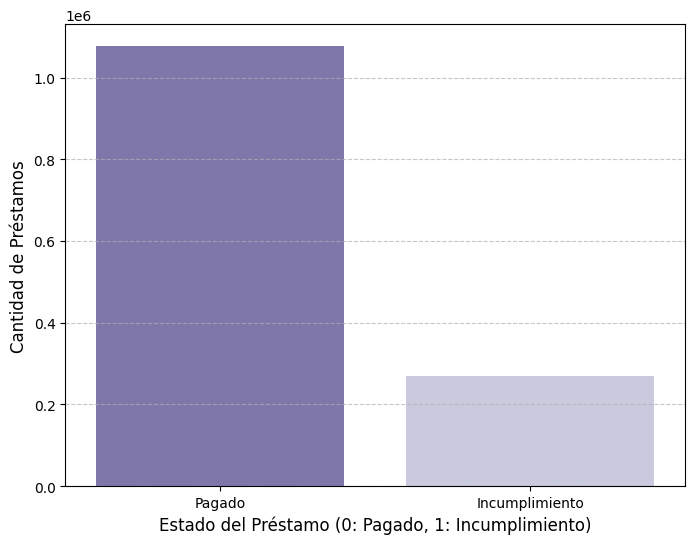

In [9]:
plt.figure(figsize=(8, 6))
sns.countplot(
    x="default",
    hue="default",
    data=df_filtered,
    palette="Purples_r",
    legend=False
)

plt.xlabel("Estado del Préstamo (0: Pagado, 1: Incumplimiento)", fontsize=12)
plt.ylabel("Cantidad de Préstamos", fontsize=12)
plt.xticks(ticks=[0, 1], labels=["Pagado", "Incumplimiento"])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


La variable objetivo `default` indica si un préstamo fue impagado. Al analizar su distribución, se observa un **desequilibrio significativo**:

- **Clase minoritaria (default = 1.0):** representa solo el **19.96%** de los datos, es decir, los que tinene un imcumplimiento en sus pagos. 
- **Clase mayoritaria (no default = 0.0):** constituye el **80.04%** de los datos, siendo predominante el pago total de los préstamos.

En el gráfico se puede evidenciar mejor este desbalance de clases, el cual se tomará las medidas necesarias para tratarlo.
 


## *Datos faltantes*

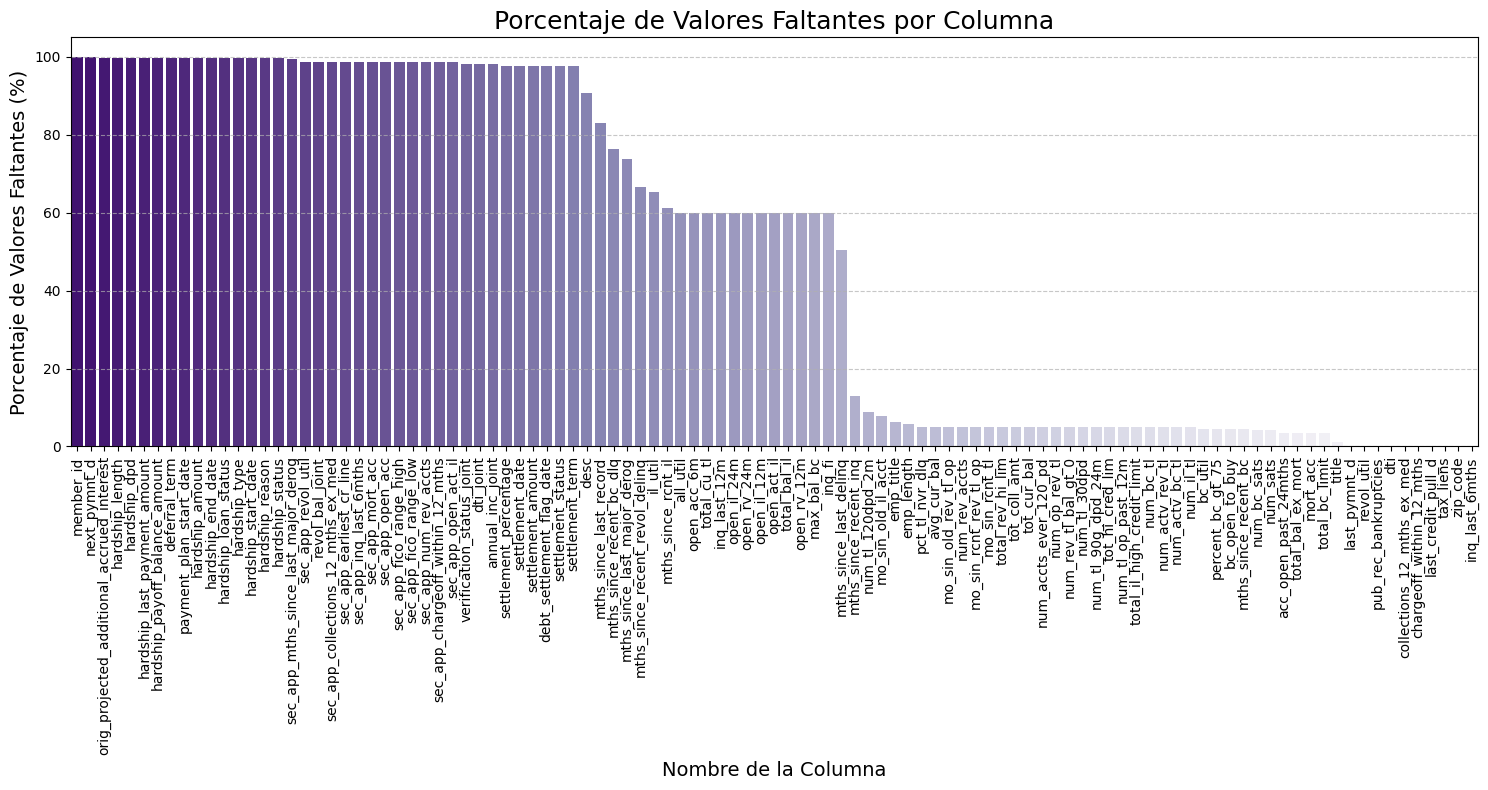

In [10]:
missing_percentage = (df_filtered.isnull().sum() / len(df_filtered)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]
missing_percentage = missing_percentage.sort_values(ascending=False)


plt.figure(figsize=(15, 8))
sns.barplot(
    x=missing_percentage.index,
    y=missing_percentage.values,
    hue=missing_percentage.index,   
    palette="Purples_r",
    legend=False                   
)


plt.title('Porcentaje de Valores Faltantes por Columna', fontsize=18)
plt.xlabel('Nombre de la Columna', fontsize=14)
plt.ylabel('Porcentaje de Valores Faltantes (%)', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

El siguiente paso es eliminar aquellas columnas que contienen un **porcentaje excesivamente alto de valores faltantes**, pues no proporcionan infromación valiosa ni hay forma de imputar sin causar sesgo. 

En este caso, se estableció un umbral del **50%**: 

In [11]:
threshold = 0.50 

missing_percentage = df_filtered.isnull().sum() / len(df_filtered)

columns_to_drop = missing_percentage[missing_percentage > threshold].index

df_filtered = df_filtered.drop(columns=columns_to_drop)

print(f"Columnas eliminadas (más del {threshold * 100}% de NaNs):")
print(columns_to_drop.tolist())

print("Forma del nuevo DataFrame limpio:")
df_filtered

Columnas eliminadas (más del 50.0% de NaNs):
['member_id', 'desc', 'mths_since_last_delinq', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,default
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0.0
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0.0
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0.0
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,...,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0.0
5,68426831,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,...,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,89905081,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,NaN,...,0.0,0.0,275356.0,54349.0,13100.0,77756.0,N,Cash,N,0.0
2260690,88948836,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,Chief Operating Officer,...,0.0,0.0,719056.0,148305.0,56500.0,95702.0,N,Cash,N,0.0
2260691,89996426,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,Sales Manager,...,0.0,0.0,524379.0,122872.0,15800.0,23879.0,N,Cash,N,1.0
2260692,90006534,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,Manager,...,3.0,0.0,87473.0,65797.0,10100.0,73473.0,N,Cash,N,0.0


Verifiquemos nuevamente los datos faltantes sobrentes. 

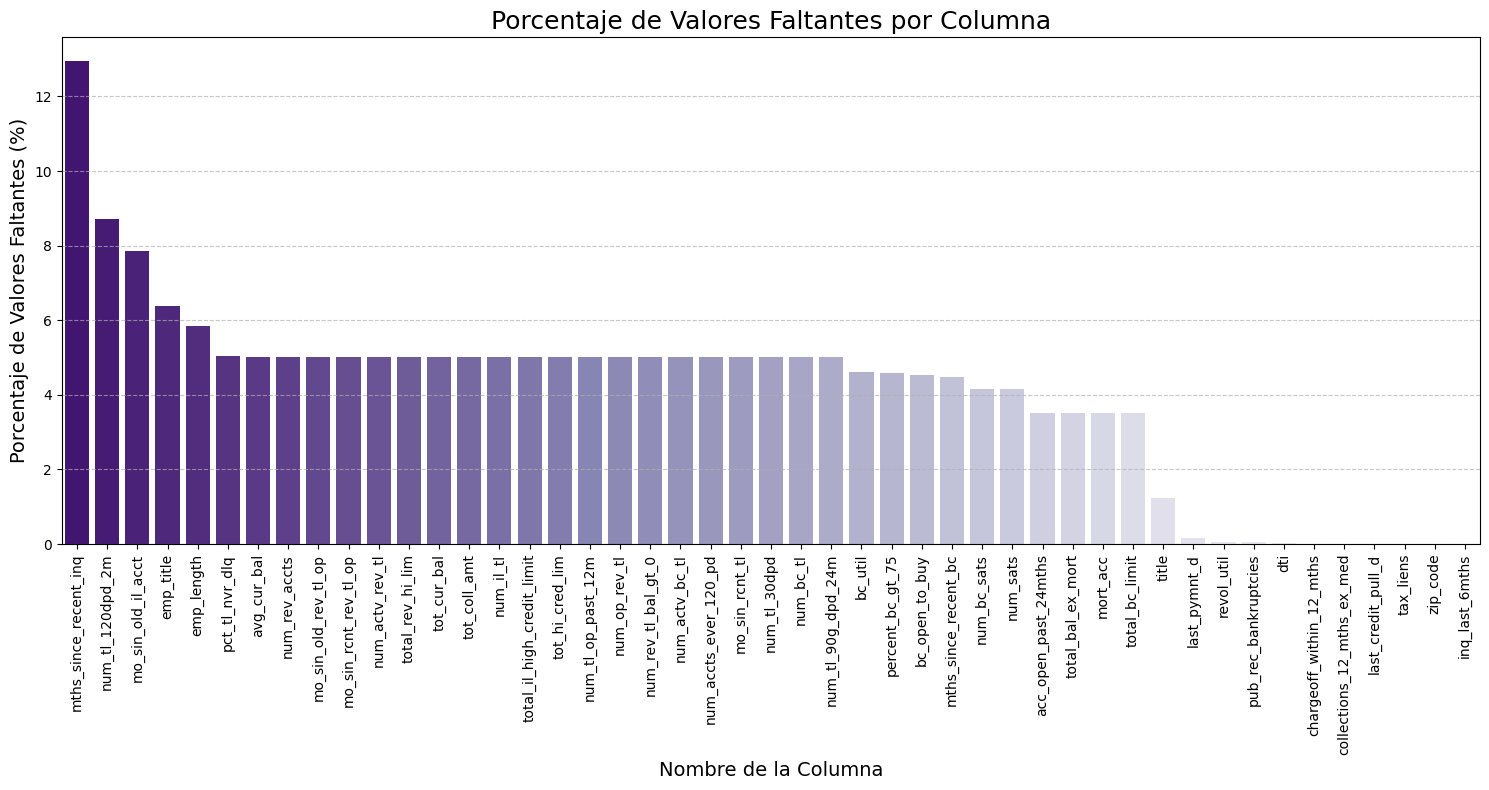

In [12]:
missing_percentage = (df_filtered.isnull().sum() / len(df_filtered)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]
missing_percentage = missing_percentage.sort_values(ascending=False)


plt.figure(figsize=(15, 8))
sns.barplot(
    x=missing_percentage.index,
    y=missing_percentage.values,
    hue=missing_percentage.index,   
    palette="Purples_r",
    legend=False                   
)


plt.title('Porcentaje de Valores Faltantes por Columna', fontsize=18)
plt.xlabel('Nombre de la Columna', fontsize=14)
plt.ylabel('Porcentaje de Valores Faltantes (%)', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Ahora procederemos a imputar por tipo de dato.

### *Variables categóricas*

In [13]:
categorical_cols = df_filtered.select_dtypes(include=['object']).columns

# 2. Contar los valores faltantes en cada una de esas columnas
missing_data = df_filtered[categorical_cols].isnull().sum()

# 3. Mostrar el resultado
print("Datos faltantes en variables categóricas:")
print(missing_data[missing_data > 0])

Datos faltantes en variables categóricas:
emp_title             85785
emp_length            78511
title                 16660
zip_code                  1
last_pymnt_d           2313
last_credit_pull_d       55
dtype: int64


In [14]:
df_filtered[["emp_title", "emp_length", "title", 
             "zip_code", "last_pymnt_d", "last_credit_pull_d"]].head(10)



,emp_title,emp_length,title,zip_code,last_pymnt_d,last_credit_pull_d
0,leadman,10+ years,Debt consolidation,190xx,Jan-2019,Mar-2019
1,Engineer,10+ years,Business,577xx,Jun-2016,Mar-2019
2,truck driver,10+ years,NaN,605xx,Jun-2017,Mar-2019
4,Contract Specialist,3 years,Major purchase,174xx,Jul-2016,Mar-2018
5,Veterinary Tecnician,4 years,Debt consolidation,300xx,May-2017,May-2017
6,Vice President of Recruiting Operations,10+ years,Debt consolidation,550xx,Nov-2016,Mar-2019
7,road driver,10+ years,Major purchase,293xx,Jan-2017,Mar-2019
8,SERVICE MANAGER,6 years,Credit card refinancing,160xx,Aug-2018,Mar-2019
9,Vendor liaison,10+ years,Credit card refinancing,029xx,Apr-2017,Nov-2018
12,Logistics Manager,3 years,NaN,275xx,Mar-2017,Sep-2018


In [15]:
df_imp = df_filtered.copy()

# Columnas categóricas a imputar con "Unknown" 
cols_to_impute = ["emp_title", "title", "zip_code", "last_pymnt_d", "last_credit_pull_d"]

# Imputación con "Unknown"
for col in cols_to_impute:
    df_imp[col] = df_imp[col].fillna("Unknown")

# Verificar imputación
print(df_imp[cols_to_impute].isnull().sum())


emp_title             0
title                 0
zip_code              0
last_pymnt_d          0
last_credit_pull_d    0
dtype: int64


In [16]:
#Variable emp_length

df_imp['emp_length'] = df_imp['emp_length'].replace('10+ years', '10')
df_imp['emp_length'] = df_imp['emp_length'].replace('< 1 year', '0')
df_imp['emp_length'] = df_imp['emp_length'].str.replace(' years', '')
df_imp['emp_length'] = df_imp['emp_length'].str.replace(' year', '')

# Convertir la columna a tipo numérico (float)
df_imp['emp_length'] = pd.to_numeric(df_imp['emp_length'])

# Imputar los valores faltantes (NaNs) con la mediana
median_emp_length = df_imp['emp_length'].median()
df_imp['emp_length'] = df_imp['emp_length'].fillna(median_emp_length)

# Verificar el resultado
print("Valores únicos en la columna 'emp_length' después de la transformación:")
print(df_imp['emp_length'].value_counts())
print("\nTipo de dato de la columna 'emp_length':", df_imp['emp_length'].dtype)

Valores únicos en la columna 'emp_length' después de la transformación:
emp_length
10.0    442199
6.0     141244
2.0     121743
0.0     108061
3.0     107597
1.0      88494
5.0      84154
4.0      80556
8.0      60701
7.0      59624
9.0      50937
Name: count, dtype: int64

Tipo de dato de la columna 'emp_length': float64


### *Variables numéricas*

In [17]:
numerical_cols = df_imp.select_dtypes(include=['number']).columns

# 2. Contar los valores faltantes en cada una de esas columnas
missing_data = df_imp[numerical_cols].isnull().sum()

# 3. Mostrar el resultado
print("Datos faltantes en variables numéricas:")
print(missing_data[missing_data > 0])

Datos faltantes en variables numéricas:
dti                              374
inq_last_6mths                     1
revol_util                       857
collections_12_mths_ex_med        56
tot_coll_amt                   67527
tot_cur_bal                    67527
total_rev_hi_lim               67527
acc_open_past_24mths           47281
avg_cur_bal                    67549
bc_open_to_buy                 61143
bc_util                        61912
chargeoff_within_12_mths          56
mo_sin_old_il_acct            105575
mo_sin_old_rev_tl_op           67528
mo_sin_rcnt_rev_tl_op          67528
mo_sin_rcnt_tl                 67527
mort_acc                       47281
mths_since_recent_bc           60221
mths_since_recent_inq         174071
num_accts_ever_120_pd          67527
num_actv_bc_tl                 67527
num_actv_rev_tl                67527
num_bc_sats                    55841
num_bc_tl                      67527
num_il_tl                      67527
num_op_rev_tl                  6752

In [18]:
# Crear el imputador (con mediana)
imputer = SimpleImputer(strategy='median')

# Aplicar al DataFrame en las columnas numéricas
df_imp[numerical_cols] = imputer.fit_transform(df_imp[numerical_cols])

# Verificar
print(df_imp[numerical_cols].isnull().sum())


loan_amnt                     0
funded_amnt                   0
funded_amnt_inv               0
int_rate                      0
installment                   0
                             ..
tot_hi_cred_lim               0
total_bal_ex_mort             0
total_bc_limit                0
total_il_high_credit_limit    0
default                       0
Length: 71, dtype: int64


# **Limpieza de datos**

En esta etapa se realizará la **limpieza de la base de datos** siguiendo distintos criterios con el fin de garantizar la calidad de la información antes del modelado.  

Con estas acciones se busca:  
- Reducir el ruido.  
- Evitar data leakage.  
- Preparar un conjunto de datos **consistente y confiable**.

In [19]:
print(df_imp.columns)


Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
       'collections_12_mths_ex_med', 'policy_code', 'application_type',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_

### *Eliminación de Variables: Fuga de Datos*

Estas columnas contienen datos que solo están disponibles **después de que el préstamo ha sido otorgado y comienza su ciclo de pagos**, lo cual falsearía la capacidad predictiva del modelo, ya que en la realidad dicha información no estaría disponible al momento de decidir sobre la solicitud. Por lo tanto, se ha decidido como primer paso eliminarlas y reducir el número de variables. 

### Tipos de columnas eliminadas  

1. **Variables que reflejan pagos o desempeño futuro del préstamo**  
   - Ejemplos: - `total_pymnt`, `total_pymnt_inv`, `total_rec_prncp`, `total_rec_int`, `total_rec_late_fee`, `recoveries`, `collection_recovery_fee`, `last_pymnt_amnt`    
   - Estas variables resumen cuánto se ha pagado del préstamo, intereses o recuperaciones. Su presencia implica conocer de antemano el resultado, lo cual invalida el modelo.

2. **Variables de fechas relacionadas con pagos futuros**  
   - Ejemplos: `last_pymnt_d` `last_credit_pull_d`.
   - Se refieren a fechas posteriores a la emisión del préstamo, imposibles de conocer en el momento de la solicitud.

3. **Variables asociadas a estados de dificultad financiera o reestructuración**  
   - Ejemplos: `hardship_flag`. 
   - Representan situaciones de incumplimiento o renegociación del préstamo, que solo se manifiestan tras haber sido otorgado.

4. **Variables relacionadas con procesos de liquidación o acuerdos de pago**  
   - Ejemplos: `debt_settlement_flag`.
   - Indican acciones posteriores de cobranza o acuerdos de pago, totalmente desconocidos al inicio.

5. **Variables derivadas de saldos pendientes y rangos crediticios finales**  
   - Ejemplos: `out_prncp`, `out_prncp_inv`, `last_fico_range_high`, `last_fico_range_low`.  
   - Reflejan la evaluación crediticia posterior, no disponible en el momento inicial de la decisión.

En conclusión, eliminar estas variables garantiza que el modelo solo utilice información **disponible al momento de otorgar el préstamo**, evitando un sesgo artificial por *data leakage* y mejorando la validez de las predicciones.

In [20]:
leakage_columns = [
   'total_pymnt', 'recoveries', 'last_pymnt_d', 'total_pymnt_inv', 'hardship_flag', 
   'last_credit_pull_d', 'last_fico_range_high', 'total_rec_int', 'collection_recovery_fee', 
   'last_pymnt_amnt', 'total_rec_prncp', 'last_fico_range_low', 'out_prncp', 'total_rec_late_fee', 
   'out_prncp_inv', 'debt_settlement_flag']

initial_columns_count = df_imp.shape[1]
df_imp = df_imp.drop(columns=[col for col in leakage_columns if col in df_imp.columns])
columns_removed_count = initial_columns_count - df_imp.shape[1]

print(f"Columnas eliminadas: {columns_removed_count}")
print(f"Columnas restantes: {df_imp.shape[1]}")

Columnas eliminadas: 16
Columnas restantes: 77


### *Eliminación de variables: Baja Varianza y baja importancia*

1. Valores únicos

In [21]:
unique_value_threshold = 0.80

# Crear una lista para almacenar las columnas a eliminar
cols_to_drop = []

# Iterar sobre cada columna del DataFrame
for col in df_imp.columns:
    # Calcular el número de valores únicos
    unique_count = df_imp[col].nunique()
    # Calcular el porcentaje de valores únicos
    unique_percentage = unique_count / len(df_imp)
    
    # Si el porcentaje supera el umbral, añadir la columna a la lista de eliminación
    if unique_percentage > unique_value_threshold:
        cols_to_drop.append(col)
        print(f"Columna '{col}': {unique_count} valores únicos ({unique_percentage:.2%} del total). Se eliminará.")

df_imp = df_imp.drop(columns=cols_to_drop)

Columna 'id': 1345310 valores únicos (100.00% del total). Se eliminará.
Columna 'url': 1345310 valores únicos (100.00% del total). Se eliminará.


2. Variables numéricas con un solo valor.

In [22]:
cols_to_drop_constant = []

for col in df_imp.columns:
    if df[col].nunique() <= 1:
        cols_to_drop_constant.append(col)
        print(f"Columna '{col}' tiene un solo valor. Se eliminará.")

# Eliminar las columnas identificadas
df_imp = df_imp.drop(columns=cols_to_drop_constant)

print(f"\nColumnas con varianza cero eliminadas: {cols_to_drop_constant}")

Columna 'policy_code' tiene un solo valor. Se eliminará.

Columnas con varianza cero eliminadas: ['policy_code']


3. Variables categóricas de un solo valor. 

In [23]:
cols_to_drop_constant = []
for col in df_imp.select_dtypes(include=['object']).columns:
    if df_imp[col].nunique() <= 1:
        cols_to_drop_constant.append(col)
        print(f"Columna '{col}' tiene un solo valor. Se eliminará.")
df_imp = df_imp.drop(columns=cols_to_drop_constant)
print(f"\nColumnas con un solo valor eliminadas: {cols_to_drop_constant}")

Columna 'pymnt_plan' tiene un solo valor. Se eliminará.

Columnas con un solo valor eliminadas: ['pymnt_plan']


### *Eliminación de variables: Redundancia*

In [24]:
numeric_df_final = df_imp.select_dtypes(include=np.number)

# Calcular la matriz de correlación
corr_matrix = numeric_df_final.corr()

# Desenvolver la matriz para obtener pares de variables
corr_unstacked = corr_matrix.stack().reset_index()
corr_unstacked.columns = ['Variable_1', 'Variable_2', 'Correlacion']

# Eliminar la correlación de una variable consigo misma (que siempre es 1)
corr_unstacked = corr_unstacked[corr_unstacked['Variable_1'] != corr_unstacked['Variable_2']]

# Ordenar por el valor absoluto de la correlación para encontrar las más altas
top_correlations = corr_unstacked.iloc[
    (-corr_unstacked['Correlacion'].abs()).argsort()
]

# Mostrar los resultados
print("--- Top 10 de pares de variables con mayor correlación positiva ---")
print(top_correlations[top_correlations['Correlacion'] > 0].head(20))

print("\n--- Top 10 de pares de variables con mayor correlación negativa ---")
print(top_correlations[top_correlations['Correlacion'] < 0].head(10))

--- Top 10 de pares de variables con mayor correlación positiva ---
               Variable_1           Variable_2  Correlacion
532        fico_range_low      fico_range_high     1.000000
589       fico_range_high       fico_range_low     1.000000
58            funded_amnt            loan_amnt     0.999562
1               loan_amnt          funded_amnt     0.999562
117       funded_amnt_inv          funded_amnt     0.999095
60            funded_amnt      funded_amnt_inv     0.999095
2               loan_amnt      funded_amnt_inv     0.998567
116       funded_amnt_inv            loan_amnt     0.998567
740              open_acc             num_sats     0.983828
2564             num_sats             open_acc     0.983828
2531  num_rev_tl_bal_gt_0      num_actv_rev_tl     0.982058
2189      num_actv_rev_tl  num_rev_tl_bal_gt_0     0.982058
1213          tot_cur_bal      tot_hi_cred_lim     0.972951
3094      tot_hi_cred_lim          tot_cur_bal     0.972951
62            funded_amnt       

Se puede evidenciar que hay un alto número de variables correlacionadas positivamente entre sí. Miremos ahora un gráfico para ilustrar en su totalidad en la base de datos. 

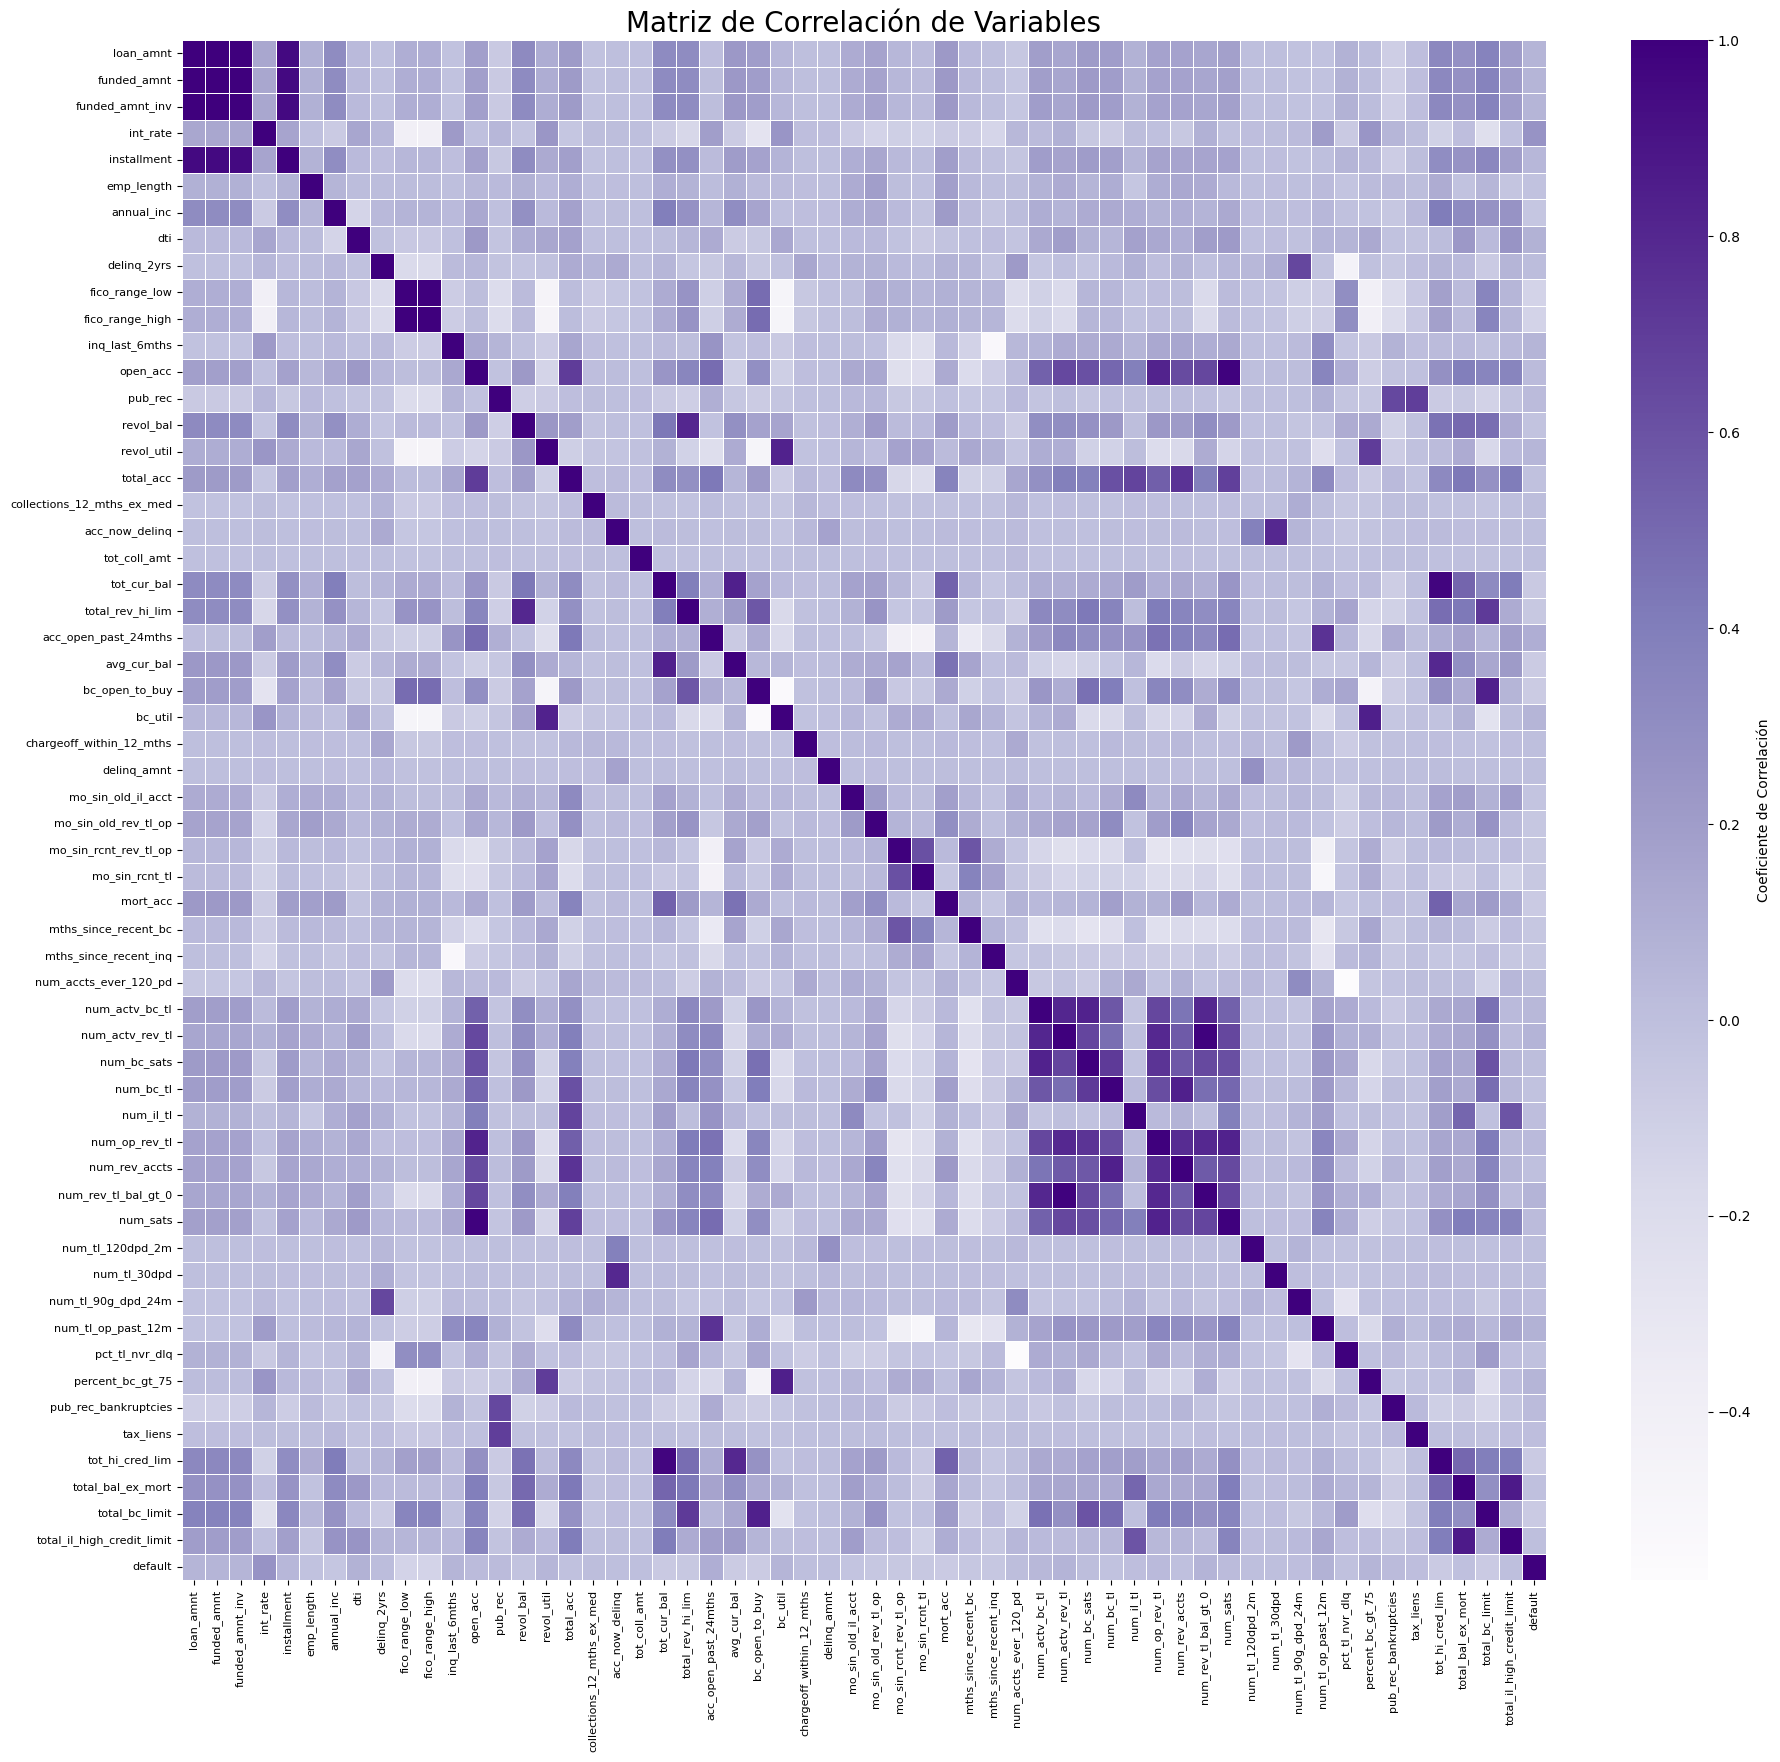

In [25]:
plt.figure(figsize=(22, 20))
sns.heatmap(
    corr_matrix,
    annot=False,   
    cmap='Purples',
    linewidths=.5,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)
plt.title('Matriz de Correlación de Variables', fontsize=20)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.show()




Como se puede observar en el gráfico, existen bloques de variables con correlaciones muy altas, algunas cercanas a 1, lo que indica una relación casi lineal entre ellas. A continuación, se identificarán las variables más correlacionadas para analizar su redundancia y decidir cuáles conviene eliminar para optimizar el modelo.
 

In [26]:
target = 'default'
threshold = 0.8  

# 1. Subset numéricas
numeric_df = df_imp.select_dtypes(include=['int64', 'float64'])

# 2. Matriz de correlación
corr_matrix = numeric_df.corr()

# 3. Guardar resultados
results = []

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # evitar duplicados
            corr_value = corr_matrix.loc[col1, col2]
            if abs(corr_value) > threshold:
                corr_with_target_1 = corr_matrix.loc[col1, target] if col1 != target else np.nan
                corr_with_target_2 = corr_matrix.loc[col2, target] if col2 != target else np.nan
                
                # sugerencia: quedarse con la de mayor correlación con el target
                if abs(corr_with_target_1) > abs(corr_with_target_2):
                    suggestion = f"Conservar {col1}"
                else:
                    suggestion = f"Conservar {col2}"
                
                results.append({
                    "var1": col1,
                    "var2": col2,
                    "corr_entre_vars": corr_value,
                    "corr_var1_obj": corr_with_target_1,
                    "corr_var2_obj": corr_with_target_2,
                    "sugerencia": suggestion
                })

# 4. Pasar a DataFrame
corr_pairs = pd.DataFrame(results)


tabla_corr = corr_pairs.style.set_caption("Análisis de Correlaciones Altas") \
    .set_properties(**{
        'font-size': '10pt',
        'border': '1px solid black',
        'background-color': '#EDE7F6',  
        'color': 'black'
    }) \
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#7E57C2'),  
                   ('font-weight', 'bold'),
                   ('color', 'white')]}
    ]) \
    .set_properties(subset=['sugerencia'], **{'font-weight': 'bold', 'color': '#4A148C'}) \
    .hide(axis='index')

display(tabla_corr)



var1,var2,corr_entre_vars,corr_var1_obj,corr_var2_obj,sugerencia
funded_amnt,loan_amnt,0.999562,0.065658,0.065604,Conservar funded_amnt
funded_amnt,funded_amnt_inv,0.999095,0.065658,0.065445,Conservar funded_amnt
funded_amnt,installment,0.954053,0.065658,0.051701,Conservar funded_amnt
funded_amnt_inv,loan_amnt,0.998567,0.065445,0.065604,Conservar loan_amnt
funded_amnt_inv,installment,0.953064,0.065445,0.051701,Conservar funded_amnt_inv
installment,loan_amnt,0.953401,0.051701,0.065604,Conservar loan_amnt
fico_range_high,fico_range_low,1.000000,-0.130682,-0.130683,Conservar fico_range_low
revol_bal,total_rev_hi_lim,0.801189,-0.020010,-0.050178,Conservar total_rev_hi_lim
tot_cur_bal,tot_hi_cred_lim,0.972951,-0.067133,-0.074505,Conservar tot_hi_cred_lim
avg_cur_bal,tot_cur_bal,0.836222,-0.074760,-0.067133,Conservar avg_cur_bal


### Grupo “Monto del Préstamo”

Variables relacionadas:  
- `loan_amnt`  
- `funded_amnt`  
- `funded_amnt_inv`  
- `installment`  

**Decisión:** Conservar `funded_amnt`.

**Justificación:**  
- Su correlación con la variable objetivo (`default`) es prácticamente igual a la de las otras variables del grupo.  
- Representa el **monto realmente aprobado** por la plataforma, lo cual tiene mayor relevancia que el monto solicitado (`loan_amnt`).  
- La variable `installment` (cuota mensual) es un valor **derivado** que depende de `funded_amnt` y del plazo del préstamo (`term`), por lo que no añade información nueva.  


In [27]:
cols_to_drop = ["loan_amnt", "funded_amnt_inv", "installment"]

df_imp = df_imp.drop(columns=cols_to_drop)

### Grupo “Crédito actual vs histórico”

Variables relacionadas:  
- `tot_cur_bal`  
- `tot_hi_cred_lim`  
- `avg_cur_bal`   

**Decisión:** Conservar `avg_cur_bal`.

**Justificación:** 
- Resume de manera más interpretable el comportamiento crediticio del cliente, ya que refleja el saldo promedio por cuenta.
- Evita sesgo asociado al número de cuentas o montos totales que sí afectan a `tot_cur_bal` y `tot_hi_cred_lim`.
- Es una medida estandarizada y comparable entre clientes, reduciendo redundancia en la información.


In [28]:
cols_to_drop = ["tot_cur_bal", "tot_hi_cred_lim"]

df_imp = df_imp.drop(columns=cols_to_drop)

### Grupo “Utilización de crédito”

Variables relacionadas:

- `bc_util` 
- `revol_util`
- `percent_bc_gt_75`

**Decisión:** Conservar `bc_util`.

**Justificación:**

- `bc_util` mide la utilización de líneas bancarias específicas, generalmente más relacionadas con el riesgo crediticio inmediato.
- `revol_util` es más general, pero suele estar correlacionada con múltiples fuentes de deuda.
- `percent_bc_gt_75` es un derivado categórico de bc_util, por lo que es redundante.

In [29]:
cols_to_drop = ["revol_util", "percent_bc_gt_75"]

df_imp = df_imp.drop(columns=cols_to_drop)

### Grupo “Actividad de cuentas”

Variables relacionadas:  
- `num_actv_bc_tl`  
- `num_actv_rev_tl`  
- `num_rev_tl_bal_gt_0`
- `num_bc_sats`

**Decisión:** Conservar `num_actv_rev_tl`.

**Justificación:**  
- Es la variable más directamente relacionada con la actividad actual en líneas revolventes, que suelen ser más riesgosas que las líneas cerradas.
- `num_bc_sats` y `num_actv_bc_tl`l aportan información redundante.
- `num_rev_tl_bal_gt_0` está muy correlacionada con `num_actv_rev_tl` y no añade independencia.

In [30]:
cols_to_drop = ["num_actv_bc_tl", "num_bc_sats", "num_rev_tl_bal_gt_0"]

df_imp = df_imp.drop(columns=cols_to_drop)

### Grupo “Líneas abiertas y satisfactorias”  

Variables relacionadas:  
- `num_op_rev_tl`  
- `num_sats`  
- `open_acc`  

**Decisión:** Conservar `open_acc`.  

**Justificación:**  
- Resume de manera más general el número de cuentas abiertas.  
- `num_op_rev_tl` y `num_sats` representan subconjuntos de `open_acc`.  
- `open_acc` permite una visión más integral sin perder información relevante.  


In [31]:
cols_to_drop = ["num_sats", "num_op_rev_tl"]

df_imp = df_imp.drop(columns=cols_to_drop)

### Variables sin grupo

In [32]:
cols_to_drop = ["fico_range_high", "revol_bal", "total_bc_limit", "total_il_high_credit_limit"]

df_imp = df_imp.drop(columns=cols_to_drop)

In [33]:
df_imp.shape


(1345310, 57)

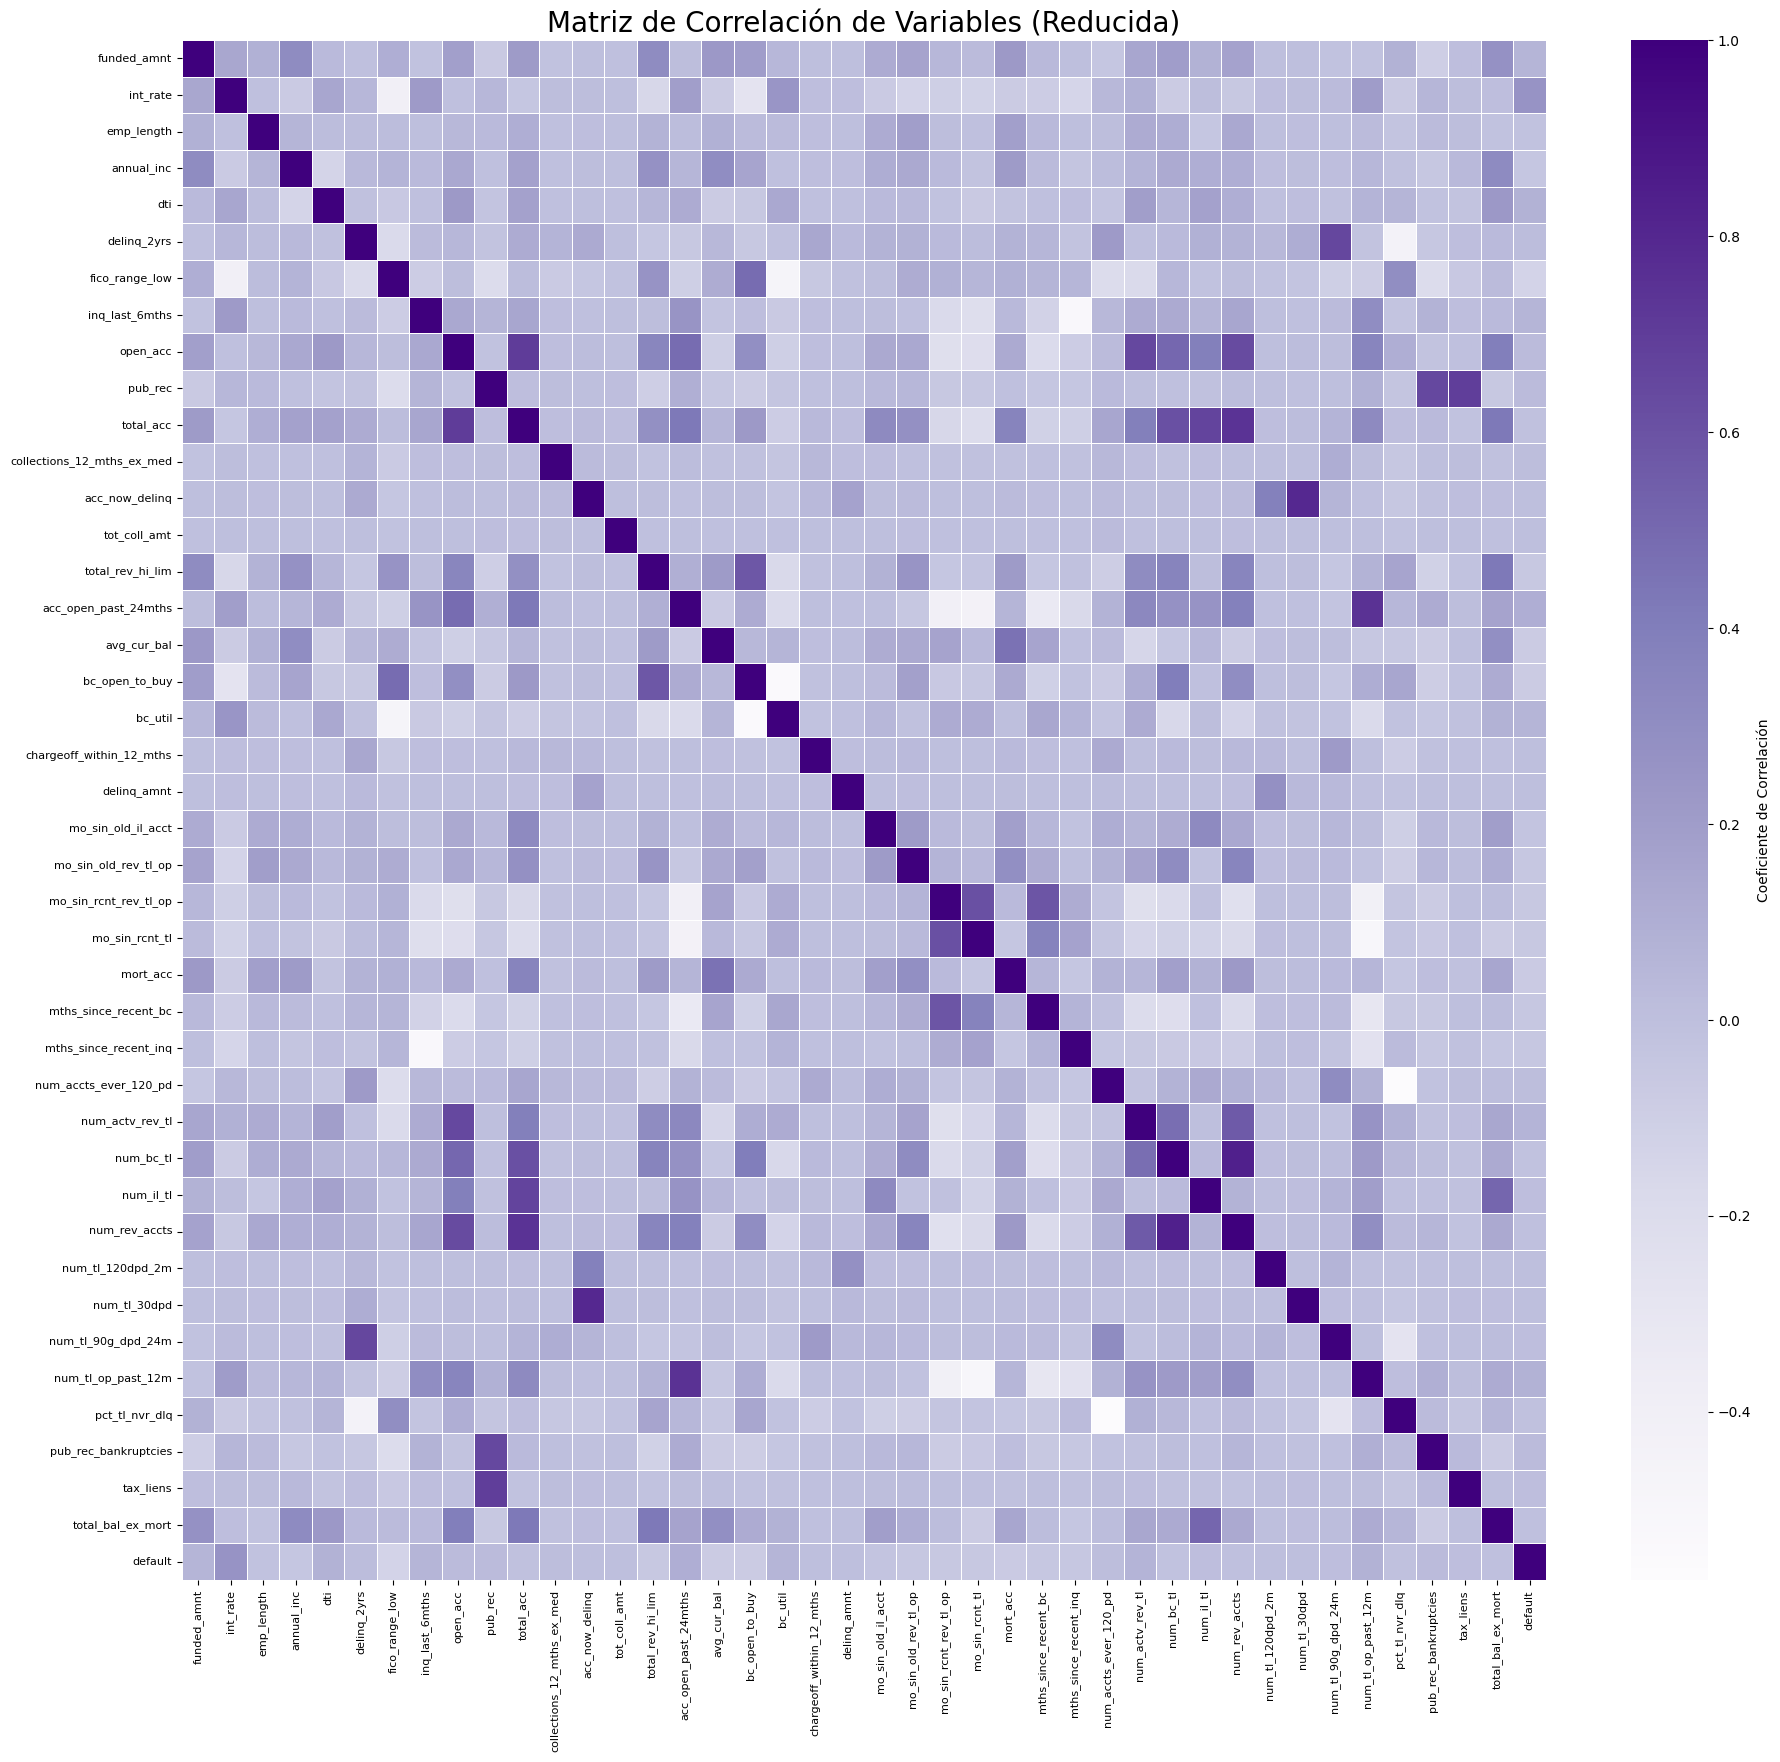

In [34]:
corr_matrix = df_imp.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(22, 20))
sns.heatmap(
    corr_matrix,
    annot=False,   # puedes cambiar a True si quieres ver los valores
    cmap='Purples',
    linewidths=.5,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)

plt.title('Matriz de Correlación de Variables (Reducida)', fontsize=20)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.show()


### Multicolinealidad

Aunque ya se realizó una depuración inicial eliminando variables altamente correlacionadas y seleccionando aquellas con mayor relevancia según el contexto y su relación con la variable objetivo, se procederá también con un análisis de multicolinealidad. Esto permitirá asegurar que no persistan dependencias lineales fuertes entre las variables restantes y garantizar mayor estabilidad en el modelo, reduciendo posibles redundancias y fortaleciendo la robustez de los resultados.  


In [35]:
X = df_imp.drop(columns=['default'])

X_numeric = X.select_dtypes(include=np.number)

vif_threshold = 5

while True:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_numeric.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_numeric.values, i)
        for i in range(len(X_numeric.columns))
    ]

    # Encontrar la variable con el VIF más alto
    max_vif = vif_data['VIF'].max()

    if max_vif > vif_threshold:
        # Identificar la variable a eliminar
        drop_feature = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']

        print(f"Eliminando '{drop_feature}' con un VIF de {max_vif:.2f}")

        # Eliminar la variable del DataFrame numérico
        X_numeric = X_numeric.drop(columns=[drop_feature])

        # Eliminar también la variable directamente de df_imp
        df_imp = df_imp.drop(columns=[drop_feature])

    else:
        print("\nTodos los valores VIF están por debajo del umbral.")
        break


Eliminando 'fico_range_low' con un VIF de 243.65
Eliminando 'total_acc' con un VIF de 125.90
Eliminando 'pct_tl_nvr_dlq' con un VIF de 32.28
Eliminando 'num_rev_accts' con un VIF de 23.14
Eliminando 'open_acc' con un VIF de 17.12
Eliminando 'int_rate' con un VIF de 10.05
Eliminando 'pub_rec' con un VIF de 9.43
Eliminando 'acc_open_past_24mths' con un VIF de 8.62
Eliminando 'mo_sin_old_il_acct' con un VIF de 8.24
Eliminando 'bc_util' con un VIF de 7.49
Eliminando 'num_bc_tl' con un VIF de 6.81
Eliminando 'mo_sin_old_rev_tl_op' con un VIF de 5.61
Eliminando 'num_actv_rev_tl' con un VIF de 5.23

Todos los valores VIF están por debajo del umbral.


### *Eliminación de variables: Análisis profundo de categóricas*

In [36]:
categorical_cols = df_imp.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['term', 'grade', 'sub_grade', 'emp_title', 'home_ownership',
       'verification_status', 'issue_d', 'purpose', 'title', 'zip_code',
       'addr_state', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'disbursement_method'],
      dtype='object')


In [37]:
df_imp[['term', 'grade', 'sub_grade', 'emp_title', 'home_ownership',
       'verification_status', 'issue_d', 'purpose', 'title', 'zip_code',
       'addr_state', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'disbursement_method']].head(10)

,term,grade,sub_grade,emp_title,home_ownership,verification_status,issue_d,purpose,title,zip_code,addr_state,earliest_cr_line,initial_list_status,application_type,disbursement_method
0,36 months,C,C4,leadman,MORTGAGE,Not Verified,Dec-2015,debt_consolidation,Debt consolidation,190xx,PA,Aug-2003,w,Individual,Cash
1,36 months,C,C1,Engineer,MORTGAGE,Not Verified,Dec-2015,small_business,Business,577xx,SD,Dec-1999,w,Individual,Cash
2,60 months,B,B4,truck driver,MORTGAGE,Not Verified,Dec-2015,home_improvement,Unknown,605xx,IL,Aug-2000,w,Joint App,Cash
4,60 months,F,F1,Contract Specialist,MORTGAGE,Source Verified,Dec-2015,major_purchase,Major purchase,174xx,PA,Jun-1998,w,Individual,Cash
5,36 months,C,C3,Veterinary Tecnician,RENT,Source Verified,Dec-2015,debt_consolidation,Debt consolidation,300xx,GA,Oct-1987,w,Individual,Cash
6,36 months,B,B2,Vice President of Recruiting Operations,MORTGAGE,Not Verified,Dec-2015,debt_consolidation,Debt consolidation,550xx,MN,Jun-1990,f,Individual,Cash
7,36 months,B,B1,road driver,MORTGAGE,Not Verified,Dec-2015,major_purchase,Major purchase,293xx,SC,Feb-1999,w,Individual,Cash
8,36 months,A,A2,SERVICE MANAGER,RENT,Not Verified,Dec-2015,credit_card,Credit card refinancing,160xx,PA,Apr-2002,w,Individual,Cash
9,36 months,B,B5,Vendor liaison,MORTGAGE,Not Verified,Dec-2015,credit_card,Credit card refinancing,029xx,RI,Nov-1994,w,Individual,Cash
12,36 months,C,C2,Logistics Manager,MORTGAGE,Not Verified,Dec-2015,other,Unknown,275xx,NC,Jun-1996,w,Individual,Cash


A plena vista, se puede observar que las variables **`purpose`** y **`title`** son **redundantes**, ya que ambas representan el **motivo del préstamo**.  

- **`purpose`**:  
  - Es una **categoría predefinida** y estandarizada por LendingClub.    

- **`title`**:  
  - Es un campo de **texto libre** escrito directamente por el solicitante.  


| **purpose**            | **title**                      |
|-------------------------|--------------------------------|
| debt_consolidation      | Debt consolidation             |
| small_business          | Business                       |
| home_improvement        | Home Improvement Loan          |
| credit_card             | Credit card refinancing        |
| wedding                 | My wedding expenses            |

  

Conservaremos únicamente **`purpose`**, por ser más **estructurada, limpia y consistente**.  

---

Las variables **`grade`** y **`sub_grade`** están directamente relacionadas y, de hecho, una es un desglose de la otra.

- **`grade`**:  
  - Representa una **clasificación general de riesgo crediticio**.  

- **`sub_grade`**:  
  - Es una subdivisión más granular de `grade`.  

| **grade** | **sub_grade** |
|-----------|---------------|
| A         | A1, A2, A3, A4, A5 |
| B         | B1, B2, B3, B4, B5 |
| C         | C1, C2, C3, C4, C5 |
| D         | D1, D2, D3, D4, D5 |


 En este caso, para evitar redundancia, conservaremos `sub_grade` y eliminaremos `grade`. 


---

Otras variables a eliminar:

- **`emp_title`**: Texto libre con demasiada variabilidad (miles de categorías distintas como “engineer”, “driver”, “teacher”). No aporta valor predictivo y genera ruido.  
- **`zip_code`**: Información demasiado granular y dispersa. Además, el riesgo crediticio no depende de un código postal específico.  
- **`addr_state`**: Puede tener cierta relación con factores macroeconómicos, pero en este dataset suele ser poco relevante y añade riesgo de sobreajuste.  
- **`initial_list_status`** y **`disbursement_method`**: Variables con muy poca variación (casi todos los registros tienen el mismo valor). No aportan información.  



In [38]:
vars_to_drop = [
    "emp_title", 
    "title", 
    "zip_code", 
    "addr_state", 
    "initial_list_status", 
    "disbursement_method", 
    "grade"
]

# Eliminar las columnas
df_imp = df_imp.drop(columns=vars_to_drop)

Tras realizar un exhaustivo proceso de tratamiento y limpieza de datos, incluyendo la imputación de valores faltantes, la eliminación de variables redundantes y la reducción de multicolinealidad, el DataFrame resultante queda depurado y optimizado para el análisis posterior. Gracias a estas acciones, hemos logrado reducir el número de variables de más de 100 a un total de 37, conservando únicamente aquellas que aportan información relevante y significativa para la modelación. Este conjunto de datos limpio y estructurado constituye la base sólida sobre la cual construiremos nuestros multilayers perceptron.


In [39]:
df_imp.head(5)

,funded_amnt,term,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,dti,...,num_accts_ever_120_pd,num_il_tl,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pub_rec_bankruptcies,tax_liens,total_bal_ex_mort,default
0,3600.0,36 months,C4,10.0,MORTGAGE,55000.0,Not Verified,Dec-2015,debt_consolidation,5.91,...,2.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,7746.0,0.0
1,24700.0,36 months,C1,10.0,MORTGAGE,65000.0,Not Verified,Dec-2015,small_business,16.06,...,0.0,6.0,0.0,0.0,0.0,2.0,0.0,0.0,39475.0,0.0
2,20000.0,60 months,B4,10.0,MORTGAGE,63000.0,Not Verified,Dec-2015,home_improvement,10.78,...,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,18696.0,0.0
4,10400.0,60 months,F1,3.0,MORTGAGE,104433.0,Source Verified,Dec-2015,major_purchase,25.37,...,0.0,10.0,0.0,0.0,0.0,4.0,0.0,0.0,95768.0,0.0
5,11950.0,36 months,C3,4.0,RENT,34000.0,Source Verified,Dec-2015,debt_consolidation,10.20,...,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,12798.0,0.0


In [40]:
# Guardar el DataFrame limpio en un nuevo CSV
#df_imp.to_csv("df_final.csv", index=False)


# **Análisis post tratamiento**

In [41]:
numeric_cols = df_imp.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('default')

print("Variables numéricas:")
print(numeric_cols)

Variables numéricas:
['funded_amnt', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'total_rev_hi_lim', 'avg_cur_bal', 'bc_open_to_buy', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_il_tl', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pub_rec_bankruptcies', 'tax_liens', 'total_bal_ex_mort']


In [42]:
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")

## *Histogramas*

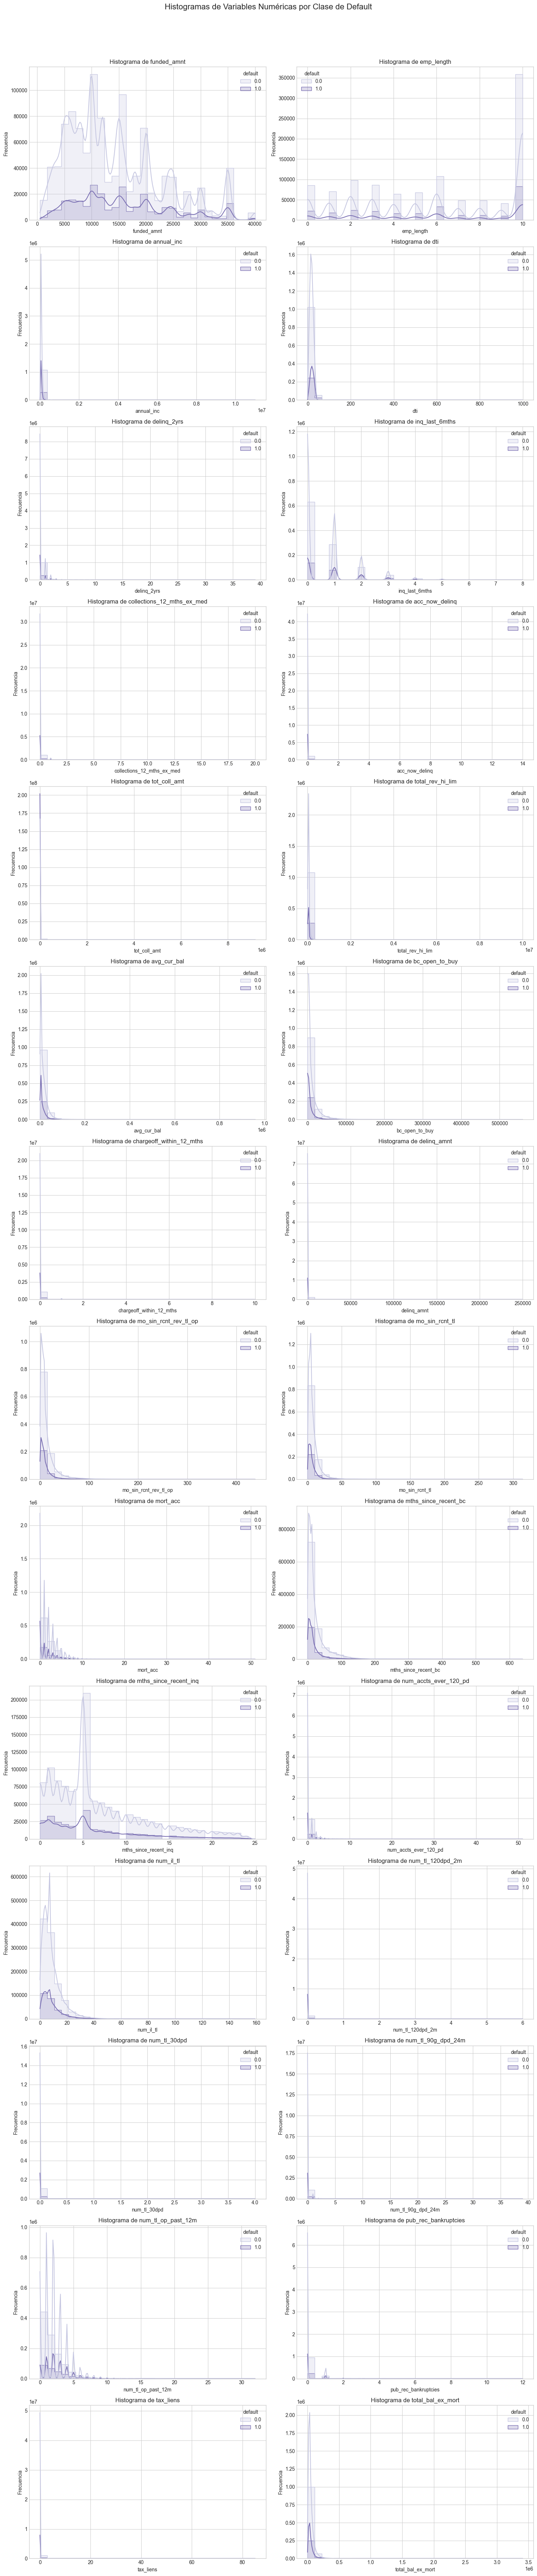

In [44]:
import math

n_cols = 2  
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.histplot(
        data=df_imp,
        x=col,
        hue='default',
        kde=True,
        bins=30,
        palette='Purples',
        element="step"
    )
    
    plt.title(f'Histograma de {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frecuencia', fontsize=10)

plt.tight_layout()
plt.suptitle('Histogramas de Variables Numéricas por Clase de Default', y=1.02, fontsize=16)
plt.show()


## *Boxplots por clase*


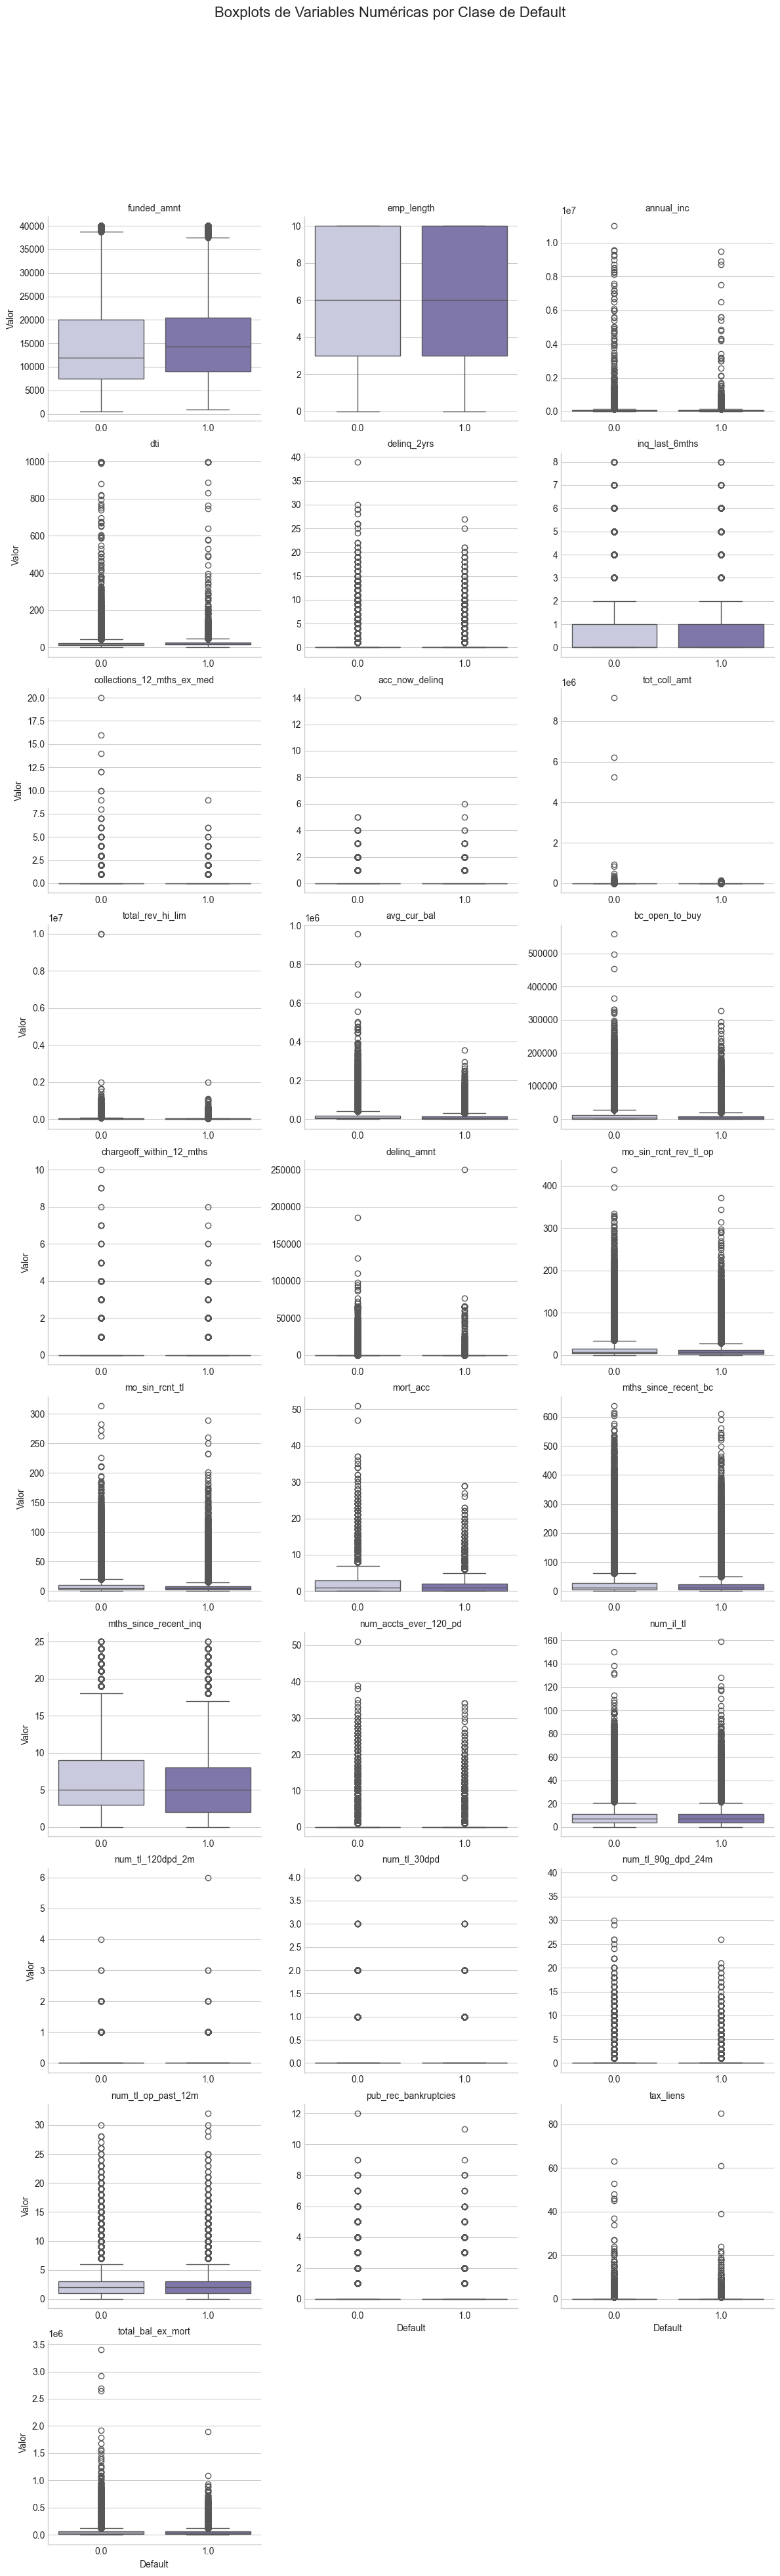

In [47]:
melted = df_imp.melt(id_vars='default', value_vars=numeric_cols,
                     var_name='variable', value_name='valor')

# Crear FacetGrid con 3 columnas por fila
g = sns.FacetGrid(melted, col="variable", col_wrap=3, sharex=False, sharey=False, height=4)

# Ahora asignamos hue="default" y quitamos la leyenda redundante
g.map_dataframe(sns.boxplot, x="default", y="valor", hue="default", palette="Purples", legend=False)

# Ajustes visuales
g.set_axis_labels("Default", "Valor")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Boxplots de Variables Numéricas por Clase de Default", fontsize=16)

plt.show()